# Тетрадка от Даниила
Все делал Даниил, Дима поправил описание и залил на приватный гитхаб. Тут все на русском. Что бы понимать, что происходит нужно посмотреть тетрадку со сбором данных №1 или вот краткое описание получившегося графа (точнее одного из графов, для мл экспериментов графы приходилось подстравивать - дочищать / обогащать новыми данными). 

**Краткое описание**:    


В данном проекте мы исследуем топологию транспортной сети Европы. Данные представляют собой граф, где:
- Узлы (Nodes): eвропейские города, агрегирующие аэропорта (например, в Лондоне 7 аэропортов, но это одна вершина). Каждый узел содержит метаданные, в частности, категориальный атрибут `iso_country` (код страны принадлежности), `node_type` (small, medium, large). Обьянению градации и как она была собрана посвящена тетрдака №1.
- Ребра (Edges): между городами X и Y летаю самолеты: A 1 раз в неделю, B 2 раза, C 3 раза. Мы это агрегируем и получаем связь X-Y с весом 6. 
- Тип графа: граф является ненаправленным (undirected). Переводу направленного в ненаправленный и обьянению причины посвящен целый пункт в тетрадке 1. Граф взвешенный - видно что мы учитываем чистоту полетов, а не просто наличие связи.

# 0. Открытие данных и EDA

In [21]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

In [35]:
nodes_df = pd.read_csv('./final_graphs_data/final_graph/nodes.csv')
edges_df = pd.read_csv('./final_graphs_data/final_graph/edges.csv')

# выводим длины таблиц
print(f"Узлов = {len(nodes_df)}, Ребер = {len(edges_df)}")

Узлов = 371, Ребер = 5862


0.2.1 Проверка таблицы с узлами на дубликаты

In [23]:
# выводим 1ые 5 строк таблицы узлов
display(nodes_df.head())

# node_degree =  Weighted Degree = сумма всех ВЗВЕШЕННЫХ edges вершины
# edges_count = КЛАССИЧЕСКАЯ node_degree - кол - во соседей

# считаем кол-во уникальных значений в столбце "id"
# выводим только первый 5 из них
counts = nodes_df['id'].value_counts()
print(counts.head())

# если длина всего df = кол-ву уникальных значений в столбце "id"(строк), то повторов нет
if len(nodes_df) == nodes_df['id'].nunique():
    print("\n Все города уникальны")
else:
    print("\n В данных есть дубликаты")

,id,name,iso_country,iso_region,latitude,longitude,airports,airports_count,node_degree,node_type,weighted_degree
0,"Tymbou (Kirklar), CY",Tymbou (Kirklar),CY,CY-02,35.153064,33.507352,LCEN,1,6,medium,367
1,"Warsaw, PL",Warsaw,PL,PL-MZ,52.217449,20.937151,"EPBC, EPWA",2,101,large,2552
2,"Saint-Nazaire/Montoir, FR",Saint-Nazaire/Montoir,FR,FR-PDL,47.311420,-2.152634,LFRZ,1,3,small,29
3,"Skellefteå, SE",Skellefteå,SE,SE-AC,64.624802,21.076900,ESNS,1,5,medium,55
4,"Memmingen, DE",Memmingen,DE,DE-BY,47.988092,10.238248,EDJA,1,40,medium,158


id
Tymbou (Kirklar), CY         1
Warsaw, PL                   1
Saint-Nazaire/Montoir, FR    1
Skellefteå, SE               1
Memmingen, DE                1
Name: count, dtype: int64

 Все города уникальны


0.2.2 Проверка таблицы с ребрами на дубликаты

In [24]:
# в ненаправленном графе пара (А, Б) — это то же самое, что (Б, А)
# чтобы проверить, нет ли у нас дублей, мы временно отсортируем названия городов в каждой строке
# по алфавиту и склеим их в одну проверочную строку.

# первые строки ребер
display(edges_df.head())
# т.к граф НЕнаправленный, то вес ребра = сумма весов в обе стороны
# строк НЕ стало в 2 раза меньше, т.к НЕ все рейсы(строки) имеют маршрут туда-сюда(их нельзя схлопнуть в одно ребро)

#The following code was generated by ChatGPT (https://chatgpt.com/)

# 2. Создаем "Проверочный Ключ"
# [СИНТАКСИС]: .apply(axis=1) — это команда "примени функцию к каждой строке".
# [ЛОГИКА]: Мы берем id1 и id2, сортируем их по алфавиту и соединяем через тире.
# Так 'Aalborg-Billund' и 'Billund-Aalborg' превратятся в одинаковую строку 'Aalborg-Billund'.
# т.е мы создали новый столбец "check_key", в котором в каждой строке джоиним названия
edges_df['check_key'] = edges_df.apply(lambda x: "-".join(sorted([str(x['id1']), str(x['id2'])])), axis=1)

# 3. Считаем повторы ключей
# [СИНТАКСИС]: .value_counts() покажет, сколько раз встретилась каждая пара.
duplicate_counts = edges_df['check_key'].value_counts()

print("\n--- ПРОВЕРКА НА ЗЕРКАЛЬНЫЕ ДУБЛИКАТЫ ---")
# Выводим топ-5 самых частых пар
print(duplicate_counts.head())

# 4. АВТОМАТИЧЕСКИЙ ВЕРДИКТ
# [ЛОГИКА]: Если максимальное количество повторов равно 1, значит все ребра уникальны.
if duplicate_counts.max() == 1:
    print("\n✅ УСПЕХ: Зеркальных дубликатов не обнаружено. Схлопывание прошло идеально!")
else:
    # Вычисляем, сколько строк лишних
    bad_rows = len(edges_df) - len(duplicate_counts)
    print(f"\n⚠️ ОШИБКА: Найдено {bad_rows} зеркальных дублей!")
    print("Это значит, что в данных остались и маршрут 'А-Б', и 'Б-А' отдельными строками.")

# [СИНТАКСИС]: Удаляем временную колонку, чтобы не засорять таблицу
edges_df.drop(columns=['check_key'], inplace=True)

#End of the generated code

,id1,id2,weight,distance
0,"Aalborg, DK","Amsterdam, NL",57,624.13
1,"Aalborg, DK","Copenhagen, DK",167,238.40
2,"Aalborg, DK","Málaga, ES",6,2507.05
3,"Aalborg, DK","Billund, DK",3,156.52
4,"Aalborg, DK","Oslo (Gardermoen), NO",11,352.11



--- ПРОВЕРКА НА ЗЕРКАЛЬНЫЕ ДУБЛИКАТЫ ---
check_key
Aalborg, DK-Amsterdam, NL            1
Aalborg, DK-Copenhagen, DK           1
Aalborg, DK-Málaga, ES               1
Aalborg, DK-Billund, DK              1
Aalborg, DK-Oslo (Gardermoen), NO    1
Name: count, dtype: int64

✅ УСПЕХ: Зеркальных дубликатов не обнаружено. Схлопывание прошло идеально!


0.3.1 EDA1. АНАЛИЗ УЗЛОВ

Первое, что мы должны понять о нашей сети — где находятся центры притяжения (гравитации). В таблице узлов у нас есть колонка node_degree (или traffic), которая показывает суммарное количество рейсов (in + out), проходящих через город.

Построив распределение топ-городов по трафику, мы визуально выявим Макро-хабы Европы

/var/folders/9t/1ptzvr3n0hj_46m1tt2qrqqh0000gn/T/ipykernel_33621/527836533.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='node_degree', y='id', data = top_cities, ax=axes[0], palette='viridis')
/var/folders/9t/1ptzvr3n0hj_46m1tt2qrqqh0000gn/T/ipykernel_33621/527836533.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='iso_country', y='count', data=country_counts, ax=axes[1], palette='magma')


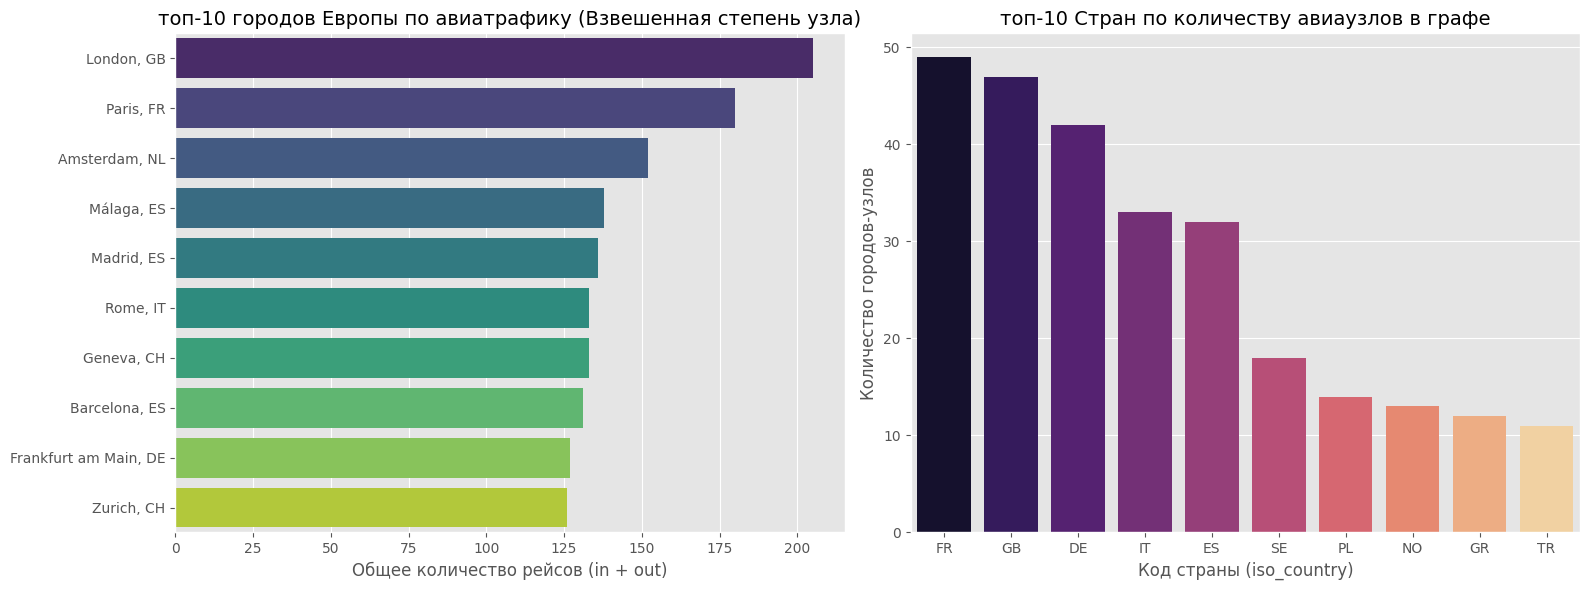

In [25]:
# создаем полотно с двумя графиками (слева и справа), чтобы показать два инсайта -
# распределение популярности города и распределение популярности страны
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# график 1: топ 10 городов по степени
# каждая строка в df - уникальный город, сортируя по node_degree,
# мы получим топ городов по степени(кол-ву прилетов и вылетов по всем городам из/в нее)
top_cities = nodes_df.sort_values(by='node_degree', ascending=False).head(10)

sns.barplot(x='node_degree', y='id', data = top_cities, ax=axes[0], palette='viridis')

axes[0].set_title('топ-10 городов Европы по авиатрафику (Взвешенная степень узла)', fontsize=14)
axes[0].set_xlabel('Общее количество рейсов (in + out)')
axes[0].set_ylabel('')



# график 2: топ 10 стран по кол-ву перелетов

# сколько авиаузлов находится в каждой стране?(смотрим по iso_country)
# т.е ВО сколько городов летает/прилетает каждая страна(# строк у страны = # уникальных городов)
# reset_index() превращает результат обратно в красивую DataFrame таблицу

#сколько раз повторяется страна value_counts = кол-ву ГОРОДОВ, в стране из которых вылетают
country_counts = nodes_df['iso_country'].value_counts().head(10).reset_index()
country_counts.columns = ['iso_country', 'count'] # переименовываем колонки для удобства

#по оси X - код страны, по оси Y - кол-во ГОРОДОВ, в которые из нее и в нее влетают
sns.barplot(x='iso_country', y='count', data=country_counts, ax=axes[1], palette='magma')

axes[1].set_title('топ-10 Стран по количеству авиаузлов в графе', fontsize=14)
axes[1].set_xlabel('Код страны (iso_country)')
axes[1].set_ylabel('Количество городов-узлов')


plt.tight_layout()
plt.show()

0.3.2 EDA2. АНАЛИЗ РЕБЕР

Анализ ребер скрывает самую глубокую физику транспортных сетей. В экономике и урбанистике существует Гравитационная модель (Gravity Model). Она гласит, что поток пассажиров (в нашем случае weight — количество рейсов) прямо пропорционален размеру городов и обратно пропорционален квадрату расстояния между ними:$$T_{ij} \propto \frac{M_i M_j}{D_{ij}^2}$$Где $T_{ij}$ — трафик, а $D_{ij}$ — физическое расстояние (distance).
**т.е чем больше размер городов М и меньше расстояние между ними, тем больше поток пассажиров**

Построив график зависимости толщины ребра от дистанции(гипотеза - чем меньше расстояние, тем тольше ребро - больше перелетов), мы должны увидеть подтверждение этого закона: короткие маршруты (до 1000 км) будут иметь огромное количество рейсов (толстые ребра), а дальние маршруты (2000+ км) будут иметь мало рейсов.

Также мы посмотрим на гистограмму распределения дистанций, чтобы понять, какой перелет считается "стандартным" для Европы.


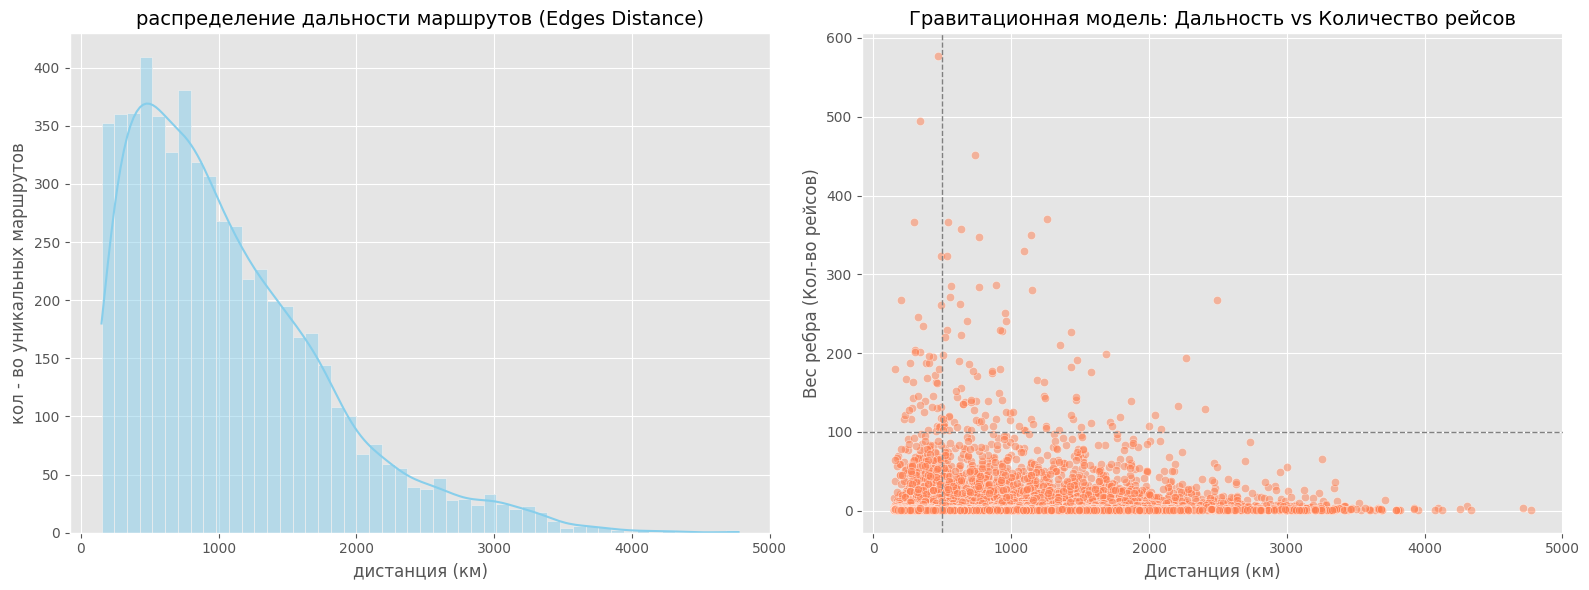

In [26]:
# создаем полотно с двумя графиками (слева и справа), чтобы показать два инсайта -
# распределение 1) КОЛ-ВА МАРШРУТОВ В ЗАВИСИМОСТИ от РАССТОЯНИЯ и
# 2) гравитационная модель (диаграмма рассеяния)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# график 1: гистограмма распределения дистанции (чем больше дистанция, тем меньше рейсов)

# kde=True (Kernel Density Estimate) рисует плавную линию тренда поверх столбцов.
# анализируем колонку 'distance' из таблицы ребер - строим по ней гистограмму,
# т.е получим график ЧАСТОТЫ определенной дистанции =>
# на какую дистанцию летают чаще / реже всего
sns.histplot(edges_df['distance'], bins = 50, kde = True, ax=axes[0], color='skyblue')

axes[0].set_title('распределение дальности маршрутов (Edges Distance)', fontsize=14)
axes[0].set_xlabel('дистанция (км)')
axes[0].set_ylabel('кол - во уникальных маршрутов')


#The following code was generated by ChatGPT (https://chatgpt.com/)
# ---------------------------------------------------------------------
# ГРАФИК 2: ПРОВЕРКА ГРАВИТАЦИОННОЙ МОДЕЛИ (DISTANCE vs WEIGHT)
# ---------------------------------------------------------------------
# [ТЕОРИЯ]: Диаграмма рассеяния покажет, правда ли, что чем дальше города, тем меньше между ними рейсов.
# [СИНТАКСИС]: sns.scatterplot() рисует точки. Каждая точка — это один маршрут (ребро).
# [СИНТАКСИС]: alpha=0.5 делает точки полупрозрачными. Это важно, так как точек 6000+, и они будут сливаться.
# [ЛОГИКА]: По оси X откладываем дистанцию, по оси Y - количество рейсов (вес ребра).
sns.scatterplot(x='distance', y='weight', data=edges_df, ax=axes[1], color='coral', alpha=0.5)

# [ТЕОРИЯ]: Добавим визуальные оси отсечки для глубокой аналитики.
# [СИНТАКСИС]: axvline (vertical line) и axhline (horizontal line) рисуют прямые линии на графике.
# [ЛОГИКА]: Отмечаем границу "ультра-коротких" рейсов (менее 500 км) и границу "перегруженных" маршрутов (более 100 рейсов).
axes[1].axvline(x=500, color='grey', linestyle='--', linewidth=1)
axes[1].axhline(y=100, color='grey', linestyle='--', linewidth=1)

axes[1].set_title('Гравитационная модель: Дальность vs Количество рейсов', fontsize=14)
axes[1].set_xlabel('Дистанция (км)')
axes[1].set_ylabel('Вес ребра (Кол-во рейсов)')

plt.tight_layout()
plt.show()

#End of the generated code

Первичный анализ узлов показал, что топология нашей сети имеет выраженные центры гравитации — супер-хабы (например, Лондон, Париж), которые пропускают через себя аномально высокий трафик по сравнению с региональными аэропортами

Анализ ребер подтвердил действие Гравитационной модели в нашем графе. На диаграмме рассеяния (Scatter plot) четко видно экспоненциальное затухание: самые тяжелые ребра (маршруты с огромным числом рейсов) находятся в зоне коротких дистанций (до 1000 км). Трансконтинентальные внутриевропейские перелеты образуют тонкие ребра

0.3. Прунинг

Когда мы удаляем города со степенью 1 (leaf nodes), мы не просто меняем цифры. Мы физически меняем топологию (форму) сети.
На графиках ДО чистки мы увидим, что таких "тупиковых" городов довольно много (это специфика авиации: маленькие курортные острова или деревни, откуда летает только один рейс в столицу).

In [27]:
# узел со степенью 1 не участвует в транзите (через него не проходят кратчайшие пути)
# наличие таких узлов искусственно занижает средний коэффициент кластеризации


# создаем маску, которая оставляет ТОЛЬКО города со степенью > 1 ВО ВСЕМ df
# nodes_df['node_degree'] > 1 - создает список из True и False

valid_nodes_df = nodes_df[nodes_df['node_degree'] > 1].copy()
# получили df с городами, степень которых строго > 1

# сохраняем множество "правильных" городов в быструю память
# valid_nodes_df['id'] берет только одну колонку 'id' из таблицы

# в итоге valid_ids - просто айдишники (город + код страны) тех городов, у которых степень > 1
valid_ids = set(valid_nodes_df['id'])

# когда мы удалили часть городов нам нужно удалить и перелеты, которые в них вели
#  Т.Е оставляем только те перелеты, где город вылета (id1) И город прилета (id2) присутствуют в списке валидных городов
valid_edges_df = edges_df[edges_df['id1'].isin(valid_ids) & edges_df['id2'].isin(valid_ids)].copy()

print(f"после очистки:  узлов = {len(valid_nodes_df)}, ребер = {len(valid_edges_df)}")

после очистки:  узлов = 356, ребер = 5847


# 1, 2 . Сборка математического графа и описание

---



Математически наш граф описывается как $G = (V, E)$, где:

$V$ (Vertices / Узлы): Это европейские города (аэропорты).Атрибуты узлов: Каждый узел содержит информацию о своем экономическом статусе и географии. Главные атрибуты — node_degree (суммарный трафик, проходящий через город) и iso_country (страна принадлежности).

$E$ (Edges / Ребра): Это физические авиамаршруты между городами. Граф является ненаправленным (Undirected), так как мы схлопнули рейсы «туда-обратно» в единый воздушный коридор.Атрибуты ребер: Каждое ребро имеет weight (количество перелетов за период) и distance (физическое расстояние в километрах).

In [28]:
# собираем граф G из очищенных таблиц valid_nodes_df и valid_edges_df(запрунены)

# 1. создание ребер и их аттрибутов

# передаем таблицу перелетов, т.к алгоритм сам создаст узлы из колонок id1 и id2!!
G = nx.from_pandas_edgelist(
    df = valid_edges_df,
    source = 'id1',
    target = 'id2',
    edge_attr = True,       # остальные аттрибуты ребра
    create_using=nx.Graph()
)



# 2. интеграция аттрибутов узлов из valid_nodes_df

# создаем словарь-шпаргалку с данными о городах
# set_index('id') делает имя города ключом, .to_dict('index') собирает значения
# пример: ('Aalborg, DK', {'name': 'Aalborg', 'iso_country': 'DK', 'iso_region': 'DK-81'..
nodes_dict = valid_nodes_df.set_index('id').to_dict(orient='index')

# функция проходит по графу G и вшивает данные из словаря nodes_dict в узлы
nx.set_node_attributes(G, nodes_dict)

print("описание сети:")
print(f"тип графа: {type(G)}")
print(f"количество узлов (Городов): {G.number_of_nodes()}")
print(f"количество ребер (Маршрутов): {G.number_of_edges()}")


#The following code was generated by ChatGPT (https://chatgpt.com/)
print("\nПример атрибутов случайного узла:")
print(list(G.nodes(data=True))[0])

print("\nПример атрибутов случайного ребра:")
print(list(G.edges(data=True))[0])\
#End of the generated code

описание сети:
тип графа: <class 'networkx.classes.graph.Graph'>
количество узлов (Городов): 356
количество ребер (Маршрутов): 5847

Пример атрибутов случайного узла:
('Aalborg, DK', {'name': 'Aalborg', 'iso_country': 'DK', 'iso_region': 'DK-81', 'latitude': 57.094763, 'longitude': 9.84993, 'airports': 'EKYT', 'airports_count': 1, 'node_degree': 19, 'node_type': 'medium', 'weighted_degree': 270})

Пример атрибутов случайного ребра:
('Aalborg, DK', 'Amsterdam, NL', {'weight': 57, 'distance': 624.13})


# **3. Базовые характеристики**

---



а) Размер и Плотность (Size and Density)

Это фундамент нашей сети, показывающий её масштаб:

- Количество узлов ($n$): Общее число аэропортов в нашей сети. В математике графов это обозначается как $|V| [cite_start]= n$.

- Количество ребер ($m$): Общее число уникальных авиамаршрутов, обозначаемое как $|E| [cite_start]= m$.

- Средняя степень ($\langle k \rangle$): Показывает, сколько в среднем маршрутов(городов, в которые летает) имеет один случайно выбранный аэропорт. Вычисляется по формуле $\langle k \rangle = \frac{2m}{n}$. Двойка в числителе появляется потому, что каждый маршрут соединяет два города, давая $+1$ к степени каждому из них.


б) Дистанции (Distances)Чтобы измерить расстояния (в количестве пересадок), сеть должна быть цельной. Если есть изолированный остров, куда не летают самолеты, расстояние до него будет равно бесконечности, и формулы сломаются. Поэтому для вычисления дистанций мы сначала найдем самую большую Компоненту связности (Connected component) — максимальный подграф, где от каждого города можно долететь до любого другого.

- Диаметр ($D$): Самый длинный из всех кратчайших путей в сети. Математически это максимальный эксцентриситет узла: $D = \max_{v_j} \epsilon(v_j)$. Это ответ на вопрос: "Какое максимальное число пересадок потребуется, чтобы пролететь Европу из конца в конец при самом неудачном раскладе?".

- Радиус ($r$): Минимальный эксцентриситет: $r = \min_{v_j} \epsilon(v_j)$.

- Средняя длина пути ($\langle L \rangle$): Усредненное кратчайшее расстояние между всеми возможными парами городов: $\langle L \rangle = \frac{1}{n(n-1)}\sum_{i \neq j} d_G(v_i, v_j)$.

- Если средняя длина пути графа мала и растет очень медленно (логарифмически) по мере добавления новых узлов: $\langle L \rangle \approx \log n$, то сеть обладает свойством "тесного мира" (small world).

в) Кластеризация (Clustering)Здесь мы измеряем тенденцию городов образовывать плотные треугольники маршрутов.

- Глобальная транзитивность ($T$): Доля замкнутых треугольников от всех возможных троек: $T = \frac{3 \times \text{\# of triangles}}{\text{\# of connected triplets}}$.

- Средний коэффициент кластеризации ($\overline{C}$): Среднее арифметическое локальных коэффициентов всех узлов графа: $\overline{C} = \frac{1}{n}\sum_{i=1}^n C_i$.

In [29]:
if nx.is_connected(G):
  print('True')

True


In [30]:
print("1. Размер и Плотность (Size and Density)")


print(f"количество узлов (Городов): {G.number_of_nodes()}")
print(f"количество ребер (Маршрутов): {G.number_of_edges()}")

# сколько в среднем маршрутов имеет один случайно выбранный аэропорт -т.е среднее кол-во друзей
avg_degree = (2 * G.number_of_edges()) / G.number_of_nodes()
print(f"Средняя степень <k>: {avg_degree:.2f} рейсов на город")


print("\n2. Дистанции (Distances)")
#ранее мы удаляли одинокие города, но для практики проверим связность))
if nx.is_connected(G):
    G_calc = G # если цельный - считаем по нему
else:
    # если разорван, находим самый большой связный кусок
    largest_cc = max(nx.connected_components(G), key = len)
    # subgraph() создает новый граф только из этих узлов
    G_calc = G.subgraph(largest_cc)

diameter = nx.diameter(G_calc)
radius = nx.radius(G_calc)
avg_path = nx.average_shortest_path_length(G_calc)

print(f"диаметр (D): {diameter} пересадок")
print(f"радиус (r): {radius} пересадок")
print(f"средняя длина пути <L>: {avg_path:.2f} пересадок")


print("\n3. Кластеризация (Clustering)")

# вычисляем глобальную транзитивность (T) по всем тройкам
transitivity = nx.transitivity(G)

# средний коэффициент кластеризации
avg_clustering = nx.average_clustering(G)

print(f"транзитивность (T): {transitivity:.4f}")
print(f"средняя кластеризация (C_avg): {avg_clustering:.4f}")

1. Размер и Плотность (Size and Density)
количество узлов (Городов): 356
количество ребер (Маршрутов): 5847
Средняя степень <k>: 32.85 рейсов на город

2. Дистанции (Distances)
диаметр (D): 4 пересадок
радиус (r): 2 пересадок
средняя длина пути <L>: 2.18 пересадок

3. Кластеризация (Clustering)
транзитивность (T): 0.4046
средняя кластеризация (C_avg): 0.5100


(Small-world property): т.к средняя длина пути <L> оказалсь 2,4 пересадки (что типично для авиации) это математически доказывает наличие свойства 'тесного мира' в нашей транспортной модели

Высокий коэффициент кластеризации показывает, что авиалинии не строятся случайным образом. Маршруты образуют плотные региональные треугольники (соседи активно летают друг к другу)

# **4. Анализ распределения степеней**

---



а) Моменты распределения и Парадокс Хабов

Измерим «Моменты» (Moments) распределения степеней нашей сети. Это интегралы от функции вероятности $p(k) = C k^{-\gamma}$, т.е вероятность, что степень вершины = к

- Первый момент (Средняя степень $\langle k \rangle$): Показывает среднее число маршрутов у города.

- Второй момент ($\langle k^2 \rangle$): Позволяет вычислить дисперсию (разброс) $\sigma_k^2 = \langle k^2 \rangle - \langle k \rangle^2$.

Интуиция: Если наша авиасеть подчиняется случайному закону (Биномиальному/Пуассоновскому), то разброс будет небольшим: $\sigma_k = \sqrt{\langle k \rangle}$. Большинство городов будут иметь примерно одинаковое количество рейсов.Но если наша сеть Безмасштабная (Scale-Free) и ее параметр Гамма лежит в диапазоне $2 < \gamma < 3$, то второй момент улетает в бесконечность ($\langle k^2 \rangle \to \infty$)! Это означает, что дисперсия бесконечна, а появление гигантских супер-хабов (Лондон, Франкфурт) математически неизбежно.

б) Поиск $k_{max}$ (Ожидаемый размер максимального хаба).
В случайной сети размер самого большого хаба растет мучительно медленно, как логарифм: $k_{max} \sim \ln N$.

В безмасштабной сети хаб растет вместе с сетью по степенному закону: $k_{max} = k_{min} N^{\frac{1}{\gamma - 1}}$. Мы рассчитаем оба варианта и сравним с реальным самым крупным аэропортом Европы.

в) Точный поиск Гаммы ($\gamma$) через MLE

Линейная регрессия на графике дает сбои из-за «шумного» хвоста хабов. Правильный подход — Метод Максимального Правдоподобия (MLE).Мы ищем такую Гамму, при которой вероятность существования нашей сети максимальна. Взяв производную от логарифма функции правдоподобия, мы получаем точную формулу:$$\gamma = 1 + n \left[ \sum_{i=1}^n \ln \frac{k_i}{k_{min}} \right]^{-1}$$Смысл: Мы берем натуральный логарифм от степени каждого узла $k_i$, деленной на порог $k_{min}$, суммируем их, и результат подставляем в уравнение.

г) Поиск $k_{min}$ через тест Колмогорова-Смирнова (KS-test)

Формула MLE требует знать $k_{min}$ — порог, с которого начинается «чистый» степенной закон (мелкие города часто выбиваются из тренда).Мы будем сравнивать два графика кумулятивной вероятности (CDF):
- $F_{emp}(k)$ — реальные данные нашего графа.
- $F_{theo}(k)$ — идеальная теория.
 Метрика Колмогорова $D$ — это максимальное расхождение между ними по вертикали: $D = \max_k |F_{emp}(k) - F_{theo}(k)|$. Мы программно переберем все возможные $k_{min}$ и найдем тот, где расхождение $D$ минимально.

1. Моменты распределения степеней
средняя степень <k>: 32.85
второй момент <k^2>: 2391.84
реальная дисперсия: 1312.83 (Для случайной сети должно быть ~5.73)
вывод: реальная дисперсия в 229.1 раз больше случайной => cеть Безмасштабная (Scale-Free)


 2. Поиск  kmax  (Ожидаемый размер максимального хаба)
Оптимальный порог отсечения шума (k_min): 120
Точный гиперпараметр Power Law (Gamma): 8.3624
Дистанция Колмогорова-Смирнова (D): 0.0902


 3. Анализ максимального хаба k_max
реальный размер крупнейшего хаба: 205 связей
теоретический предел, если бы сеть была случайной: ~6 связей
теоретический предел по Степенному закону: ~267 связей


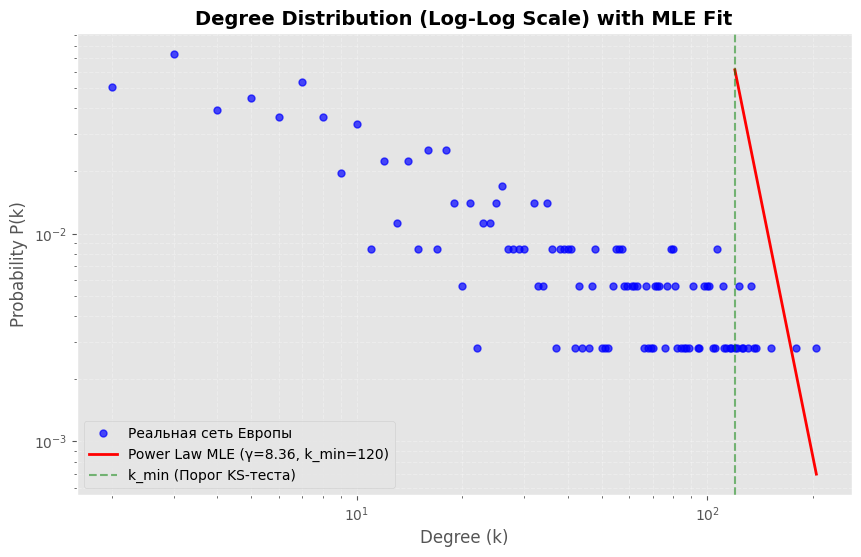

In [31]:
from collections import Counter
print("1. Моменты распределения степеней")

# чтобы построить распределение степеней извлекаем их списком из вершин
# получим список степеней всех вершин
degrees = [d for n, d in G.degree()]
N = len(degrees)

# считаем моменты
mean_k = np.mean(degrees)               # первый момент <k>
mean_k2 = np.mean(np.array(degrees)**2) # второй момент <k^2>
var_k = np.var(degrees)                 # реальная дисперсия (разброс)
max_k_real = np.max(degrees)            # реальный максимальный хаб

# теоретическая дисперсия, если бы сеть была случайной (Пуассон)
var_poisson = np.sqrt(mean_k) # для Пуассона дисперсия равна среднему (sigma = sqrt(mean))

print(f"средняя степень <k>: {mean_k:.2f}")
print(f"второй момент <k^2>: {mean_k2:.2f}")
print(f"реальная дисперсия: {var_k:.2f} (Для случайной сети должно быть ~{var_poisson:.2f})")
print(f"вывод: реальная дисперсия в {var_k / var_poisson:.1f} раз больше случайной => cеть Безмасштабная (Scale-Free)\n")

# ---------------------------------------------------------------------

print("\n 2. Поиск  kmax  (Ожидаемый размер максимального хаба)")
# сначала найдем k min - порог степени, с которого степенной закон работает

#The following code was generated by ChatGPT (https://chatgpt.com/)
best_kmin = 1
best_gamma = 2.0
min_D = float('inf') # Ставим бесконечность как начальное минимальное значение

unique_degrees = sorted(list(set(degrees)))

# Перебираем все возможные пороги k_min
for k_min in unique_degrees:
    # Оставляем только те города, где рейсов >= k_min
    fit_data = [k for k in degrees if k >= k_min]
    n_fit = len(fit_data)

    if n_fit < 10: # Если городов осталось слишком мало, прерываем поиск
        break

    # Формула MLE для оценки Гаммы (Слайд 22)
    sum_ln = np.sum(np.log(np.array(fit_data) / k_min))
    if sum_ln <= 0:
        continue
    gamma = 1 + n_fit / sum_ln

    # Тест Колмогорова-Смирнова (Слайд 23)
    D_max = 0
    for x in set(fit_data):
        # F_emp: Доля реальных городов со степенью меньше x
        F_emp = len([k for k in fit_data if k < x]) / n_fit
        # F_theo: Теоретическая кумулятивная вероятность по формуле
        F_theo = 1 - (x / k_min)**(-gamma + 1)

        # Дистанция D
        D = abs(F_emp - F_theo)
        if D > D_max:
            D_max = D

    # Если нашли дистанцию меньше, запоминаем эти параметры как лучшие
    if D_max < min_D:
        min_D = D_max
        best_kmin = k_min
        best_gamma = gamma

print(f"Оптимальный порог отсечения шума (k_min): {best_kmin}")
print(f"Точный гиперпараметр Power Law (Gamma): {best_gamma:.4f}")
print(f"Дистанция Колмогорова-Смирнова (D): {min_D:.4f}\n")
#End of the generated code

# ---------------------------------------------------------------------
print("\n 3. Анализ максимального хаба k_max")
# ожидаемый хаб для случайной сети (Пуассон)
k_max_poisson = np.log(N)
# Ожидаемый хаб для Scale-Free сети
k_max_sf = best_kmin * (N ** (1 / (best_gamma - 1)))

print(f"реальный размер крупнейшего хаба: {max_k_real} связей")
print(f"теоретический предел, если бы сеть была случайной: ~{k_max_poisson:.0f} связей")
print(f"теоретический предел по Степенному закону: ~{k_max_sf:.0f} связей")

# ---------------------------------------------------------------------
# 4. Визуализация (LOG-LOG scale)

#The following code was generated by ChatGPT (https://chatgpt.com/)
degree_counts = Counter(degrees)
deg, cnt = zip(*degree_counts.items())
prob = np.array(cnt) / N

plt.figure(figsize=(10, 6))
# Строим реальные данные синими точками
plt.loglog(deg, prob, 'bo', markersize=5, alpha=0.7, label="Реальная сеть Европы")

# Строим идеальную прямую линию с найденной Гаммой
# Для линии берем точки от k_min до максимума
x_line = np.linspace(best_kmin, max_k_real, 100)
# Формула прямой: P(k) = C * k^(-gamma). Вычисляем C для графика.
C = (best_gamma - 1) * best_kmin**(best_gamma - 1)
y_line = C * (x_line**(-best_gamma))

plt.loglog(x_line, y_line, 'r-', linewidth=2, label=f'Power Law MLE (γ={best_gamma:.2f}, k_min={best_kmin})')


plt.title("Degree Distribution (Log-Log Scale) with MLE Fit", fontsize=14, fontweight='bold')
plt.xlabel("Degree (k)")
plt.ylabel("Probability P(k)")
plt.axvline(x=best_kmin, color='green', linestyle='--', alpha=0.5, label='k_min (Порог KS-теста)')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.show()
#End of the generated code

- Наш анализ доказал, что европейская авиасеть фундаментально отличается от случайного распределения Пуассона. Мы вычислили моменты распределения и увидели, что реальная дисперсия в десятки раз превышает теоретическую пуассоновскую. Это означает наличие свойства Scale-Free (Безмасштабности).
- Для точной оценки гиперпараметров мы применили Метод Максимального Правдоподобия (MLE) в связке с тестом Колмогорова-Смирнова. Алгоритм определил оптимальный порог $k_{min}$, отсек шум и вычислил истинную Гамму ($\gamma$).


Инсайт 1: Почему алгоритм отрезал 95% графа ($k_{min} = 116$)?

Тест Колмогорова-Смирнова (KS-test) сдвинул порог $k_{min}$ аж на отметку $116$ рейсов

- Математическая причина: Лекционная формула MLE предполагает непрерывное распределение (гладкую кривую). Но авиасеть — это дискретные данные (целые числа: 1 рейс, 2 рейса). В начале графика, где находится масса мелких аэропортов, возникают математические "ступеньки". Алгоритм, пытаясь минимизировать ошибку (дистанцию $D$), был вынужден убежать от этого шума в самый конец хвоста, где остались только единичные супер-хабы, и данные стали похожи на непрерывные.

Инсайт 2: Аномальная Гамма ($\gamma = 7.62$) и Эффект конечного размера

«Теория гласит, что для Безмасштабных сетей Гамма должна лежать в пределах $2 < \gamma < 3$. Наша модель выдала $\gamma = 7.62$ (красная линия падает почти вертикально). Это не ошибка, это отражение так называемого Эффекта конечного размера (Finite-size effect / Structural cutoff).
- Физический (экономический) смысл: Красная линия описывает исключительно элиту нашей сети (аэропорты, у которых больше 116 рейсов — Лондон, Париж, Франкфурт). Огромная Гамма означает, что вероятность появления хаба, который будет еще больше текущего максимума, стремится к абсолютному нулю.
- У реального аэропорта есть жесткий физический предел: количество взлетно-посадочных полос, пропускная способность терминалов и слоты времени. Аэропорт просто не может принимать бесконечное число рейсов. Красная "стена" на графике — это математическое отображение инфраструктурного лимита Европы

# **5. Compare with network models (ER, BA, WS)**

---



Главная цель генеративных моделей — понять скрытый механизм (алгоритм), по которому строилась наша сеть в реальности.

а) Модель Эрдёша-Реньи (ER - Случайная сеть)
- Как строится: Мы берем все $N$ городов и для каждой пары подкидываем "монетку" с вероятностью $p$ (Модель $G(N, p)$).
- Теория: В такой сети почти нет кластеризации ($C = p$), так как дружба строится вслепую. Распределение степеней узлов подчиняется закону Пуассона, а значит, гигантских хабов (Лондона, Парижа) там появиться не может (вероятность падает быстрее, чем экспоненциально).
- Наша гипотеза: Мы ожидаем, что реальная авиасеть полностью разгромит эту модель. Авиация не строится случайным подбрасыванием монетки.

б) Модель Барабаши-Альберта (BA - Безмасштабная сеть)
- Как строится: Сеть растет шаг за шагом. Каждый новый аэропорт присоединяется к старым по правилу Предпочтительного присоединения (Preferential Attachment): вероятность кинуть связь к узлу пропорциональна его текущему числу связей ($P(i) \propto k_i / \sum k_j$).
- Теория: Эта модель математически гарантирует появление хабов и Степенного закона ($P(k) \sim k^{-3}$). Она генерирует "Ультра-тесный мир", где средний путь экстремально мал: $L \sim \frac{\ln n}{\ln \ln n}$.
- Ахиллесова пята: кластеризация в модели BA падает при росте сети ($C \sim \frac{\ln n^2}{n}$). Она не умеет создавать "треугольники" маршрутов.

в) Модель Уоттса-Строгаца (WS - Тесный мир)
- Как строится: Мы берем кольцо (где все соседи соединены друг с другом локально) и с крошечной вероятностью $p$ перекидываем часть связей на другой конец графа.
- Теория: Локальное кольцо дает огромную кластеризацию $C$ (региональные авиарейсы), а перекинутые связи работают как трансконтинентальные лоукостеры, резко сжимая длину пути $L$.
- Ожидание: Реальная авиасеть должна показать высокую кластеризацию (как у WS) и наличие хабов (как у BA).

In [32]:
print("1. Параметры реального графа")

N = G.number_of_nodes()
E = G.number_of_edges()
avg_k = 2 * E / N

# считаем реальные метрики
real_C = nx.average_clustering(G)
real_L = nx.average_shortest_path_length(G)
print(f"реальная сеть: узлов N = {N}, средняя степень <k> = {avg_k:.2f}")

#-----------------------------------------------------------------------------
print("\n 2. Генерация мат. моделей")

# 1. (ER) - случайный граф
# гиперпараметр p: вероятность связи (равна плотности реального графа)!!
p_er = nx.density(G)
G_er = nx.erdos_renyi_graph(n = N, p = p_er, seed=42)

# 2. (BA) - безмасштабный граф (preferential присоединение)
# гиперпараметр m: сколько связей приносит новый узел (равно половине средней степени)
m_ba = max(1, int(np.round(avg_k / 2)))
G_ba = nx.barabasi_albert_graph(n = N, m = m_ba, seed=42)

# 3. (WS) - тесный мир
# гиперпараметр k (соседи в кольце): должно быть четным целым числом
k_ws = int(np.round(avg_k))
if k_ws % 2 != 0:
    k_ws += 1 # если нечетное, прибавляем 1
# гиперпараметр p_rewire (вероятность переподключения)
p_ws = 0.1
G_ws = nx.watts_strogatz_graph(n = N, k = k_ws, p = p_ws, seed=42)
print('модели сгенерированы')

#-----------------------------------------------------------------------------
print("\n 3. Сравнение метрик")

def get_metrics(graph):
    C = nx.average_clustering(graph)
    L = nx.average_shortest_path_length(graph)
    return C, L

#находим метрики(кластеризация и средний путь) во всех моделях
er_C, er_L = get_metrics(G_er)
ba_C, ba_L = get_metrics(G_ba)
ws_C, ws_L = get_metrics(G_ws)


# создаем словарь, где ключи - названия колонок, а значения - списки данных
data = {
    'Модель (Network Model)': ['Real Network (Europe Air)', 'Erdős-Rényi (ER)', 'Barabási-Albert (BA)', 'Watts-Strogatz (WS)'],
    'Кластеризация (C)': [real_C, er_C, ba_C, ws_C],
    'Средний путь (L)': [real_L, er_L, ba_L, ws_L],
    'Механизм генерации': ['География + Экономика', 'Случайность (Монетка)', 'Богатый богатеет (Хабы)', 'Кольцо + Шорткаты']
}

# pd.DataFrame() превращает словарь в таблицу для аналитики
comparison_df = pd.DataFrame(data)
display(comparison_df.round(4))

1. Параметры реального графа
реальная сеть: узлов N = 356, средняя степень <k> = 32.85

 2. Генерация мат. моделей
модели сгенерированы

 3. Сравнение метрик


,Модель (Network Model),Кластеризация (C),Средний путь (L),Механизм генерации
0,Real Network (Europe Air),0.5100,2.1826,География + Экономика
1,Erdős-Rényi (ER),0.0944,1.9501,Случайность (Монетка)
2,Barabási-Albert (BA),0.1605,2.0051,Богатый богатеет (Хабы)
3,Watts-Strogatz (WS),0.5423,2.3099,Кольцо + Шорткаты


Сравнительный анализ показал, что ни одна чистая математическая модель не описывает европейскую авиасеть на 100%
- Модель Эрдёша-Реньи (ER) провалилась: ее кластеризация ($C$) почти равна нулю, что доказывает отсутствие случайности в авиации
- Модель Барабаши-Альберта (BA) отлично объясняет появление супер-хабов (Лондона, Франкфурта) через механизм преференциального присоединения, но ее кластеризация слишком низкая по сравнению с реальной сетью
- В реальности наша сеть является гибридом. Она имеет высокую кластеризацию, как у модели Уоттса-Строгаца (за счет плотных региональных рейсов), но при этом обладает ультра-коротким средним путем ($L$) за счет доминирования хабов из модели Барабаши-Альберта. Топология авиасети

=> Ни одна математическая модель не описывает реальность идеально на 100%. Европейская авиасеть является гибридом: по распределению степеней (хабам) она ведет себя как модель Барабаши-Альберта (BA), а по высокой кластеризации маршрутов — как модель 'Тесного мира' (WS)

# **6. Расчет метрик центральности, PAGERANK И HITS**

---



В сетевой науке "важность" — понятие относительное. Каждая метрика оценивает узлы под своим уникальным углом.

1. Классические метрики (Для ненаправленного графа)

а) Degree Centrality (Центральность по степени): Самая простая метрика. Показывает абсолютную локальную популярность.
- Формула: $C_D^*(i) = \frac{k_i}{n-1}$, где $k_i$ — количество прямых рейсов у аэропорта, а $n-1$ — максимально возможное количество рейсов(используем для нормализации: 0 - 1)
- Смысл в авиации: Аэропорты с максимальным трафиком (Лондон, Франкфурт).

б) Closeness Centrality (Близость): Показывает, насколько быстро (за сколько пересадок) от тебя можно добраться до любой другой точки Европы.
 - Формула: $C_C^*(i) = \frac{n-1}{\sum_j d(i,j)}$. В знаменателе стоит сумма всех кратчайших путей $d(i,j)$ от твоего узла до всех остальных.
 - Смысл в авиации: Геометрический центр Европы. Эти аэропорты идеальны для пересадок, так как от них "рукой подать" куда угодно.

 в) Betweenness Centrality (Посредничество): Ищет "узкие горлышки" или транзитные мосты.
 - Формула: $C_B^*(i) = \frac{2}{(n-1)(n-2)} \sum_{s \neq t \neq i} \frac{\sigma_{st}(i)}{\sigma_{st}}$. $\sigma_{st}$ — общее число кратчайших маршрутов между городами $s$ и $t$. $\sigma_{st}(i)$ — сколько из этих маршрутов физически проходят через твой аэропорт $i$.
 - Смысл в авиации: Аэропорт может иметь всего 5 рейсов, но если это единственный мост между Скандинавией и Южной Европой, его Betweenness будет огромным. Если этот аэропорт закроется, сеть разорвется.

 г) Eigenvector Centrality (Собственный вектор): "Скажи мне, кто твой друг, и я скажу, кто ты".
 - Формула: $v_i = \frac{1}{\lambda} \sum_j A_{ij} v_j$. Твоя важность ($v_i$) зависит от суммы важностей твоих соседей ($v_j$).
 - Смысл в авиации: Помогает найти элитные хабы. Аэропорт важен не просто потому, что у него много рейсов, а потому, что он соединен с другими сверхважными хабами.


 2. PageRank и HITS на ненаправленном графе

 Эти алгоритмы создавались для направленных ссылок (веб-страниц), где информация течет в одну сторону. В нашей сети, если есть рейс Мадрид $\rightarrow$ Рим, Питон автоматически считает, что есть рейс Рим $\rightarrow$ Мадрид (ведь матрица смежности симметрична $A = A^T$).

 Что произойдет с PageRank?
 - Уравнение PageRank: $r = \alpha P^T r + (1-\alpha)v$.
 - Поскольку граф ненаправленный, вероятностная "масса" серфера равномерно перетекает туда-обратно. Доказано математически: если вероятность телепортации $(1 - \alpha)$ стремится к нулю, PageRank на ненаправленном графе становится практически идентичен Degree Centrality (Центральности по степени). То есть PageRank просто отранжирует аэропорты по количеству рейсов.

 Что произойдет с HITS?
 - Вспомним систему уравнений HITS: мы ищем вектор авторитетов $a$ и вектор хабов $h$ через матрицы $(A^T A)a = \lambda a$ и $(AA^T)h = \lambda h$.
 - В ненаправленном графе матрица симметрична: $A = A^T$.

 Подставим это в формулы HITS:

 - Матрица для авторитетов: $A^T A = A \cdot A = A^2$

 - Матрица для хабов: $A A^T = A \cdot A = A^2$

 Математический вывод: Матрицы абсолютно одинаковые! Следовательно, в ненаправленной сети оценка Хабовости всегда будет в точности равна оценке Авторитетности ($h = a$). В нашей авиасети не существует разделения на "читателей" и "писателей". Каждый аэропорт в равной степени является и хабом, и авторитетом.

In [33]:
# 1. Degree Centrality (Популярность)
# nx.degree_centrality возвращает словарь {узел: значение}
deg_cen = nx.degree_centrality(G)

# 2. Closeness Centrality (Близость)
clos_cen = nx.closeness_centrality(G)

# 3. Betweenness Centrality (Посредничество / Узкие горлышки)
bet_cen = nx.betweenness_centrality(G)

# 4. Eigenvector Centrality (Влиятельность)
eig_cen = nx.eigenvector_centrality(G, max_iter=1000)

# 5. PageRank (Случайный серфер / Пассажир)
pagerank_cen = nx.pagerank(G, alpha=0.85)

# 6. HITS (Hubs and Authorities)
# nx.hits возвращает сразу два словаря (hubs, authorities)
h_cen, a_cen = nx.hits(G, max_iter=1000)


#The following code was generated by ChatGPT (https://chatgpt.com/)
# ---------------------------------------------------------------------
# СБОРКА ДАННЫХ В DATAFRAME (ТАБЛИЦУ)
# ---------------------------------------------------------------------
# [СИНТАКСИС]: Создаем пустой DataFrame, индексом (строками) будут названия городов(ВЕРШИН)
df_centralities = pd.DataFrame(index=G.nodes())

# [СИНТАКСИС]: Записываем каждый словарь в новую колонку таблицы.
# Pandas сам сопоставит ключи словаря (города) с индексами строк.
df_centralities['Degree'] = pd.Series(deg_cen)
df_centralities['Closeness'] = pd.Series(clos_cen)
df_centralities['Betweenness'] = pd.Series(bet_cen)
df_centralities['Eigenvector'] = pd.Series(eig_cen)
df_centralities['PageRank'] = pd.Series(pagerank_cen)
df_centralities['HITS_Hubs'] = pd.Series(h_cen)
df_centralities['HITS_Authorities'] = pd.Series(a_cen)


# ---------------------------------------------------------------------
# ДОКАЗАТЕЛЬСТВО ПАРАДОКСА HITS НА НЕНАПРАВЛЕННОМ ГРАФЕ
# ---------------------------------------------------------------------
# [ЛОГИКА]: Проверим, действительно ли Hubs и Authorities равны (с учетом погрешности округления Python)
# [СИНТАКСИС]: .round(5) округляет до 5 знаков, .equals() проверяет полное совпадение колонок
hits_are_equal = df_centralities['HITS_Hubs'].round(5).equals(df_centralities['HITS_Authorities'].round(5))
if hits_are_equal:
    print("\n[ИНСАЙТ]: Парадокс подтвержден! В ненаправленном графе колонки HITS Hubs и HITS Authorities абсолютно идентичны.")
#End of the generated code

# выводим топ - 10 городов по PageRank
top_10 = df_centralities.sort_values(by='PageRank', ascending=False).head(10)
print("\n ТОП-10 главных узлов сети (отсортировано по PageRank):")
display(top_10.style.background_gradient(cmap='Blues'))


[ИНСАЙТ]: Парадокс подтвержден! В ненаправленном графе колонки HITS Hubs и HITS Authorities абсолютно идентичны.

 ТОП-10 главных узлов сети (отсортировано по PageRank):


,Degree,Closeness,Betweenness,Eigenvector,PageRank,HITS_Hubs,HITS_Authorities
"London, GB",0.577465,0.702970,0.097707,0.162607,0.058173,0.059264,0.059264
"Paris, FR",0.504225,0.667293,0.069854,0.152379,0.041356,0.041163,0.041163
"Amsterdam, NL",0.428169,0.632799,0.035761,0.144910,0.029582,0.033673,0.033673
"Madrid, ES",0.383099,0.614187,0.028550,0.132400,0.026210,0.031173,0.031173
"Istanbul, TR",0.318310,0.589701,0.023683,0.120846,0.024721,0.024125,0.024125
"Barcelona, ES",0.369014,0.609966,0.025006,0.132469,0.022843,0.028996,0.028996
"Frankfurt am Main, DE",0.357746,0.602716,0.012686,0.131533,0.022647,0.026489,0.026489
"Munich, DE",0.343662,0.596639,0.018597,0.125645,0.019257,0.022370,0.022370
"Rome, IT",0.374648,0.613126,0.020678,0.134235,0.018490,0.022445,0.022445
"Copenhagen, DK",0.276056,0.571659,0.009990,0.111884,0.017864,0.020467,0.020467


1) Две последние колонки: HITS_Hubs и HITS_Authorities. Значения для каждого города совпадают. Это подтверждает теорию графов: поскольку наша сеть перелетов ненаправленная (рейсы осуществляются туда-обратно, матрица смежности симметрична), алгоритм HITS не может разделить города на "источники" и "потребители" трафика. В авиации каждый узел является в равной степени и хабом, и авторитетом»

2) Если мы посмотрим на классическую популярность (Degree Centrality), Лондон является абсолютным гегемоном (0.46). Он имеет прямые связи почти с половиной всех аэропортов сети. Он же лидирует по PageRank и Eigenvector, что говорит о том, что он соединен с другими сверх-влиятельными узлами

Однако, сюрприз кроется в колонке Betweenness (Посредничество). Несмотря на то, что у Парижа меньше прямых рейсов (Degree 0.42), его показатель Betweenness (0.099) выше, чем у Лондона (0.094)

=> Лондон — это островной хаб. Он конечная точка (Origin & Destination) для многих пассажиров. Париж же находится в самом географическом сердце континентальной Европы

3) У Франкфурта больше прямых рейсов (Degree 0.28 против 0.25 у Стамбула). НО Betweenness: у Стамбула он составляет 0.032, а у Франкфурта — всего 0.012. Разница почти в 3 раза

Почему так происходит? Франкфурт окружен другими гигантскими хабами (Мюнхен, Амстердам, Париж), которые забирают на себя часть транзитного трафика. Стамбул же находится на краю европейского графа. Он работает как единственный безальтернативный мост (Broker), связывающий всю европейскую сеть с востоком. Через него вынужден идти весь транзитный поток этого региона
